In [2]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [3]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

In [4]:
manifest

,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,...,cue_split_int,cue_sr,cue_src_fn,cue_total_file_duration_in_s,cue_word,sex_cond,excerpt_src_fn,excerpt_cue_src_fn,excerpt_distractor_1_src_fn,excerpt_distractor_2_src_fn
0,601538,laura-s,0.29,1205.07,1204.78,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1796.176689,each,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
1,638828,dolliellama,0.36,737.92,737.56,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4871.649524,behavior,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
2,249863,ama1016,0.52,371.41,370.89,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,273.502041,language,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
3,127418,popularoutcast,0.47,3399.30,3398.83,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1526.788934,ties,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
4,961747,sedola,0.42,1898.92,1898.50,swc,female,0,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,2335.023311,from,same,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,732888,jdhowens90,0.49,75.97,75.48,swc,male,1,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4936.383855,photograph,different,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
1948,430284,matthewdgonzalez,0.28,3505.95,3505.67,swc,male,1,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,4670.506667,four,different,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
1949,359887,jsharpminor,0.26,232.06,231.80,swc,male,1,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,917.921088,plane,different,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...
1950,479509,messedrocker,0.38,567.64,567.26,swc,male,1,NaN,0,...,0.0,44100.0,/scratch2/weka/mcdermott/msaddler/swc/english/...,1496.289524,splitting,different,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...


In [5]:
manifest['src_fn'][0]

'/scratch2/weka/mcdermott/msaddler/swc/english/validArticles/Binary_star/audio_combined.wav'

In [6]:
manifest['excerpt_src_fn'][0]

'/om/user/imgriff/datasets/human_word_rec_SWC_2024/sounds/target_excerpts/full_df_ix_0000_about-laura-s.wav'

## Load participant data and meta files 

## Get experiment results

In [7]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [8]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

## add pilot results 

path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_thresholds_v00')
part_results += sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/')
meta_files += sorted(list(path_to_meta_data.glob("*meta.pkl")))


# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    part_name = result_file.stem
    # remove space 
    if '007' in part_name:
        continue
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    manifest_file = manifest_dict[part_name]
    part_df = util_process.get_part_df(result_file)
    manifest_df = util_process.get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)

## add confusions 
confusions = []
for response, distractor_word in results_df[['response', 'distractor_word']].to_numpy():
    if isinstance(distractor_word, list):
        confusions.append(int(response in distractor_word))
    else:
        confusions.append(int(response == distractor_word ))

results_df['confusions'] = confusions

In [9]:
results_df.shape

(4681, 23)

In [37]:
eg_part = results_df[results_df.participant == 'participant_008'].reset_index(drop=True)

In [38]:
eg_part 


,trial_num,response,correct_response,correct,target_loc,distractor_loc,azim_delta,elev_delta,snr,target_word,...,distractor_azim,distractor_elev,n_distractors,distractor_1_word,distractor_2_word,src_fn,distractor_1_fn,distractor_2_fn,participant,confusions
0,0,battle,civil,0.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,-6,civil,...,0,-20,2,better,which,full_df_ix_0074_civil-laura-s,full_df_ix_0074_which-persian-poet-gal_eg_1,full_df_ix_0074_better-popularoutcast_eg_0,participant_008,0
1,1,except,germany,0.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,3,germany,...,30,-20,2,first,would,full_df_ix_1143_germany-laurahale,full_df_ix_1143_would-kingdon_eg_1,full_df_ix_1143_first-liverpudlian100_eg_0,participant_008,0
2,2,songs,story,0.0,"(0, -20)","[(-10, -20), (10, -20)]",10,0,0,story,...,10,-20,2,council,certain,full_df_ix_1864_story-dcoetzee,full_df_ix_1864_council-lily5lace_eg_0,full_df_ix_1864_certain-gorillawarfare_eg_1,participant_008,0
3,3,chief,chief,1.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,0,chief,...,30,-20,2,after,company,full_df_ix_0557_chief-arrowdynamicsx,full_df_ix_0557_company-batwoodman_eg_1,full_df_ix_0557_after-random2502_eg_0,participant_008,0
4,4,stage,fourth,0.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,0,fourth,...,0,-20,2,release,father,full_df_ix_1132_fourth-popularoutcast,full_df_ix_1132_release-mangst_eg_0,full_df_ix_1132_father-matthewdgonzalez_eg_1,participant_008,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,475,centre,center,0.0,"(0, -20)","[(0, 0), (0, 0)]",0,20,3,center,...,0,0,2,travel,during,full_df_ix_0551_center-pordaria,full_df_ix_0551_travel-sethda_eg_0,full_df_ix_0551_during-the-seraphim_eg_1,participant_008,0
476,476,similar,similar,1.0,"(0, -20)","[(0, 0), (0, 0)]",0,20,6,similar,...,0,0,2,called,force,full_df_ix_1349_similar-popularoutcast,full_df_ix_1349_force-pordaria_eg_1,full_df_ix_1349_called-sspungy_eg_0,participant_008,0
477,477,night,night,1.0,"(0, -20)","[(0, 0), (0, 0)]",0,20,-6,night,...,0,0,2,state,people,full_df_ix_1252_night-flyingtoaster,full_df_ix_1252_state-s-whistler_eg_0,full_df_ix_1252_people-alexkillby_eg_1,participant_008,0
478,478,instead,instead,1.0,"(0, -20)","[(0, 20), (0, 20)]",0,40,6,instead,...,0,20,2,water,among,full_df_ix_1175_instead-sophus-bie,full_df_ix_1175_among-tonyle_eg_1,full_df_ix_1175_water-halidecyphon_eg_0,participant_008,0


In [49]:
eg_part.columns

Index(['trial_num', 'response', 'correct_response', 'correct', 'target_loc',
       'distractor_loc', 'azim_delta', 'elev_delta', 'snr', 'target_word',
       'distractor_word', 'target_azim', 'target_elev', 'distractor_azim',
       'distractor_elev', 'n_distractors', 'distractor_1_word',
       'distractor_2_word', 'src_fn', 'distractor_1_fn', 'distractor_2_fn',
       'participant', 'confusions'],
      dtype='object')

2    480
Name: n_distractors, dtype: int64

In [54]:
eg_w_transcripts = pd.merge(eg_part,
         df_w_transcripts[["word", "distractor_1_word", "distractor_2_word", "targ_src_stem", 
                        "dist_1_src_stem", "dist_2_src_stem", "target_transcripts", 
                        "distractor_1_transcripts", "distractor_2_transcripts"]], 
            left_on=['correct_response', 'src_fn', 'distractor_1_fn', 'distractor_2_fn'],
            right_on=['word', 'targ_src_stem', "dist_1_src_stem", "dist_2_src_stem"],
            how='inner'
            )

In [64]:
eg_w_transcripts.head()

,trial_num,response,correct_response,correct,target_loc,distractor_loc,azim_delta,elev_delta,snr,target_word,...,confusions,word,distractor_1_word_y,distractor_2_word_y,targ_src_stem,dist_1_src_stem,dist_2_src_stem,target_transcripts,distractor_1_transcripts,distractor_2_transcripts
0,2,songs,story,0.0,"(0, -20)","[(-10, -20), (10, -20)]",10,0,0,story,...,0,story,council,certain,full_df_ix_1864_story-dcoetzee,full_df_ix_1864_council-lily5lace_eg_0,full_df_ix_1864_certain-gorillawarfare_eg_1,"[of, how, the, story, about, obamas]","[brother, and, the, kings, council, this, was,...","[bans, on, certain, illegal, content]"
1,4,stage,fourth,0.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,0,fourth,...,0,fourth,release,father,full_df_ix_1132_fourth-popularoutcast,full_df_ix_1132_release-mangst_eg_0,full_df_ix_1132_father-matthewdgonzalez_eg_1,"[after, the, fourth, stage, the, path]","[every, minor, release]","[and, her, father, otherwise]"
2,5,various,various,1.0,"(0, -20)","[(-10, -20), (10, -20)]",10,0,6,various,...,0,various,black,seven,full_df_ix_0943_various-matthewdgonzalez,full_df_ix_0943_black-epolk_eg_0,full_df_ix_0943_seven-the-voice-of-hassocks_eg_1,"[several, threats, by, various, groups, had, a...","[predominantly, in, black]","[one thousand, six hundred and sixty, seven, d..."
3,6,history,history,1.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,3,history,...,0,history,include,written,full_df_ix_0188_history-flyingtoaster,full_df_ix_0188_include-popularoutcast_eg_0,full_df_ix_0188_written-elizabeyth_eg_1,"[that, have, been, published, throughout, the,...","[countries, include, canada]","[of, the, court, again, written, by, justice, ..."
4,8,songs,music,0.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,-9,music,...,0,music,general,london,full_df_ix_0754_music-warpig1994,full_df_ix_0754_general-panser-born_eg_0,full_df_ix_0754_london-emailnewberry_eg_1,"[modern, online, music, distribution]","[there, was, general, admiration, for, the]","[hotel, in, london]"


In [67]:
df_w_transcripts[df_w_transcripts.targ_src_stem == "full_df_ix_0074_civil-laura-s"]

,manifest_ix,orig_df_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,...,distractor_1_src_fn,distractor_2_src_fn,target_transcripts,distractor_1_transcripts,distractor_2_transcripts,distractor_1_word,distractor_2_word,targ_src_stem,dist_1_src_stem,dist_2_src_stem
74,74,603762,laura-s,0.2,1262.54,1262.34,swc,female,0,NaN,...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,/om/user/imgriff/datasets/human_word_rec_SWC_2...,"[although, no, civil, war, battles]","[to, provide, better, results, to, their]","[certain, restrictions, when]",better,which,full_df_ix_0074_civil-laura-s,full_df_ix_0074_better-popularoutcast_eg_0,full_df_ix_0074_which-persian-poet-gal_eg_1


In [65]:
missing_rows = eg_part[~eg_part.trial_num.isin(eg_w_transcripts.trial_num.values)]
missing_rows.head()

,trial_num,response,correct_response,correct,target_loc,distractor_loc,azim_delta,elev_delta,snr,target_word,...,distractor_azim,distractor_elev,n_distractors,distractor_1_word,distractor_2_word,src_fn,distractor_1_fn,distractor_2_fn,participant,confusions
0,0,battle,civil,0.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,-6,civil,...,0,-20,2,better,which,full_df_ix_0074_civil-laura-s,full_df_ix_0074_which-persian-poet-gal_eg_1,full_df_ix_0074_better-popularoutcast_eg_0,participant_008,0
1,1,except,germany,0.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,3,germany,...,30,-20,2,first,would,full_df_ix_1143_germany-laurahale,full_df_ix_1143_would-kingdon_eg_1,full_df_ix_1143_first-liverpudlian100_eg_0,participant_008,0
3,3,chief,chief,1.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,0,chief,...,30,-20,2,after,company,full_df_ix_0557_chief-arrowdynamicsx,full_df_ix_0557_company-batwoodman_eg_1,full_df_ix_0557_after-random2502_eg_0,participant_008,0
7,7,former,royal,0.0,"(0, -20)","[(-10, -20), (10, -20)]",10,0,-9,royal,...,10,-20,2,former,other,full_df_ix_0351_royal-popularoutcast,full_df_ix_0351_other-ama1016_eg_1,full_df_ix_0351_former-acather96_eg_0,participant_008,1
9,9,young,people,0.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,6,people,...,30,-20,2,human,economy,full_df_ix_1762_people-sspungy,full_df_ix_1762_economy-pinangjawa_eg_1,full_df_ix_1762_human-flyingtoaster_eg_0,participant_008,0


In [8]:
# manifest = pd.read_pickle(manifest_file)
# manifest_df = pd.concat([pd.DataFrame(val.values()) for val in manifest.values()]).reset_index(drop=True)
# manifest_df.head()

In [9]:
manifest_file

PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/participant_002_pilot_meta.pkl')

In [10]:
## Drop preston's duplicated trial - is 359 with response: "trees"

results_df = results_df[~((results_df.participant == 'pilot_participant_002') & (results_df.trial_num == 359) & (results_df.response == 'trees'))].reset_index(drop=True)

In [11]:
results_df['distractor_elev_delta'] = (results_df['distractor_elev'] - results_df['target_elev']).abs()

In [12]:
results_df.participant.unique()

array(['participant_001', 'participant_002', 'participant_003',
       'participant_004', 'participant_005', 'participant_006',
       'participant_008', 'participant_009', 'pilot_participant_001',
       'pilot_participant_002'], dtype=object)

In [13]:
pilot_participants = ['participant_001', 'participant_002', 'participant_003',
       'participant_004', 'participant_005', 'pilot_participant_001', 'pilot_participant_002']

In [15]:
# Lets only use pilot/early data:
results_df = results_df[results_df.participant.isin(pilot_participants)]
# results_df = results_df[~results_df.participant.isin(['participant_001', 'participant_007','pilot_participant_001', 'pilot_participant_002'])]
# results_df = results_df[~results_df.participant.isin([ 'participant_007'])]

In [16]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'distractor_azim',
                                   'distractor_elev_delta', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]



In [17]:
# function to calculate Cohen's d for independent samples
# eg from https://machinelearningmastery.com/effect-size-measures-in-python/

def cohend(d1, d2):
	# calculate the size of samples
	n1, n2 = len(d1), len(d2)
	# calculate the variance of the samples
	s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
	# calculate the pooled standard deviation
	s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
	# calculate the means of the samples
	u1, u2 = np.mean(d1), np.mean(d2)
	# calculate the effect size
	return (u1 - u2) / s


### Get inidiviual thresholds for 0 and 10 azim conditions, then compute mean and std of their difference  (e.g. 0 - 10)



In [18]:
# avg threshold estimates for 0 and 10 azimuth separation 
azim_results = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim.isin([0, 10, 30])) & (grouped_part_results.n_distractors == 2)].copy()
azim_results_for_thresh = azim_results.groupby(['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = azim_results.participant.nunique() 

azim_results_for_thresh = azim_results_for_thresh[azim_results_for_thresh['snr'].isin(np.arange(-9, 7,3))]

azim_thresholds = []
# p0 = [0.0, -4, 4]
for (part, azim), group in azim_results_for_thresh.groupby(['participant', 'distractor_azim']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for azim {azim}")
    azim_thresholds.append({'participant':part, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_azim_thresh_df = pd.DataFrame(azim_thresholds)


azim_0 = human_azim_thresh_df[human_azim_thresh_df.azim==0]
azim_10 = human_azim_thresh_df[human_azim_thresh_df.azim==10]

diff = azim_0.threshold.values - azim_10.threshold.values

mean_diff = diff.mean()
std_diff = diff.std()

mean_diff, std_diff

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(1.6664782923610217, 2.695750356040048)

### Get mean difference in elevation

In [19]:
elev_20

NameError: name 'elev_20' is not defined

In [20]:
elev_0

NameError: name 'elev_0' is not defined

In [21]:
# avg threshold estimates for 0 and 10 elevuth separation 
elev_results = grouped_part_results[(grouped_part_results.distractor_azim == 0) & (grouped_part_results.n_distractors == 2)].copy()
elev_results = elev_results[~elev_results.participant.str.contains('pilot')]
elev_results_for_thresh = elev_results.groupby(['participant', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()

N = elev_results.participant.nunique() 
print(N)
elev_results_for_thresh = elev_results_for_thresh[elev_results_for_thresh['snr'].isin(np.arange(-9, 7, 3))]

elev_thresholds = []
# p0 = [0.0, -4, 4]
for (part, elev), group in elev_results_for_thresh.groupby(['participant', 'distractor_elev_delta']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for elev {elev}")
    elev_thresholds.append({'participant':part, 'elev': elev, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_elev_thresh_df = pd.DataFrame(elev_thresholds)


elev_0 = human_elev_thresh_df[human_elev_thresh_df.elev==0]
elev_20 = human_elev_thresh_df[human_elev_thresh_df.elev==20]

diff = elev_0.threshold.values - elev_20.threshold.values

mean_diff = diff.mean()
std_diff = diff.std()

mean_diff, std_diff

5


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(2.925511523511569, 1.5927017541057191)

## Run bootstrap using threshold estimates 

  0%|          | 0/6 [00:00<?, ?it/s]

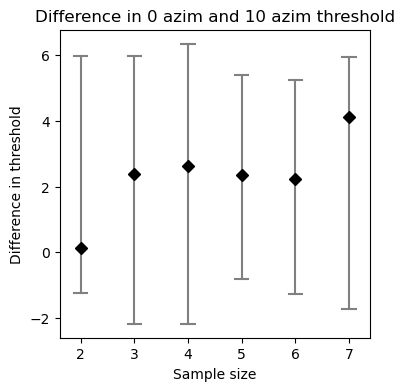

In [24]:
#### Bootstrap differences in thresholds 
azim_results = grouped_part_results.query("distractor_elev_delta == 0 & n_distractors == 2 & distractor_azim.isin([0, 10])").copy()

azim_results_for_thresh = azim_results.groupby(['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = azim_results.participant.nunique() 
unique_participants = azim_results.participant.unique()
unique_participants = unique_participants[unique_participants != 'participant001']
azim_results_for_thresh = azim_results_for_thresh[azim_results_for_thresh['snr'].isin(np.arange(-9, 7, 3))]
n_boots = 1000
samp_sizes = np.arange(2,N+1)

differences = np.zeros(n_boots)

def get_thresh_diff(args):
    unique_participants, samp_size, azim_results_for_thresh = args
    sample_parts = np.random.choice(unique_participants, samp_size, replace=True)
    samp_data = azim_results_for_thresh[azim_results_for_thresh.participant.isin(sample_parts)]
    samp_data = samp_data.groupby(['snr', 'distractor_azim']).correct_mean.mean().reset_index()
    azim_thresholds = []
    # p0 = [0.0, -4, 4]
    for (azim), group in samp_data.groupby(['distractor_azim']): #, 'gender_cond']):
        # try:
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
        azim_thresholds.append({'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        # except:
        #     azim_thresholds.append({'azim': azim, 'threshold':np.nan}) #  'gender_cond':gend_cond,
    samp_thresh_df = pd.DataFrame(azim_thresholds)
    azim_0 = samp_thresh_df[samp_thresh_df.azim==0]
    azim_10 = samp_thresh_df[samp_thresh_df.azim==10]
    diff = azim_0.threshold.values - azim_10.threshold.values
    return diff.item()

with mp.Pool(mp.cpu_count()) as pool:
    sample_diffs = {samp_size: np.array(pool.map(get_thresh_diff, [(unique_participants, samp_size, azim_results_for_thresh) for _ in range(n_boots)])) for samp_size in tqdm(samp_sizes)}


### Plot diffs as function of sample size 
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, data in sample_diffs.items():
    ci_means = np.nanmean(data)
    lower_ci, upper_ci = np.nanpercentile(data, [2.5,97.5])
    # use sem instead of percentiles
    # lower_ci = ci_means - (1.96 * scipy.stats.sem(data))
    # upper_ci = ci_means +  (1.96 * scipy.stats.sem(data))


    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Difference in 0 azim and 10 azim threshold")
plt.xlabel("Sample size")
plt.ylabel("Difference in threshold")
# set x ticks to match sample sizes 
plt.xticks(list(sample_diffs.keys()));

    # axs.plot(sample_size, upper_ci, marker='o')
    # axs.plot(sample_size, mean, marker='o')
    # axs.plot(sample_size, lower_ci, marker='o')
    # plt.errorbar(sample_size, mean,  yerr=upper_ci-lower_ci, alpha=0.3, marker='.')

In [25]:
azim_results.participant.unique() 


array(['participant_002', 'participant_003', 'participant_004',
       'participant_005', 'participant_006', 'participant_008',
       'participant_009'], dtype=object)

  0%|          | 0/7 [00:00<?, ?it/s]

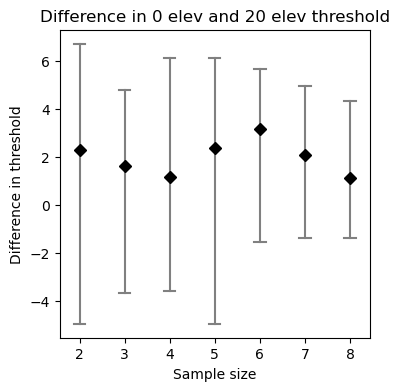

In [60]:
#### Bootstrap differences in thresholds 
elev_results = grouped_part_results[(grouped_part_results.distractor_azim == 0)  & (grouped_part_results.n_distractors == 2)].copy()
elev_results = elev_results[(elev_results['snr'].isin(np.arange(-9, 7,3)))]
elev_results = elev_results[~elev_results.participant.str.contains('pilot')]
N = elev_results.participant.nunique() 

unique_participants = elev_results.participant.unique()
elev_results_for_thresh = elev_results.groupby(['participant', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()

n_boots = 1000
samp_sizes = np.arange(2,N+1)


def get_thresh_diff(args):
    unique_participants, samp_size, elev_results_for_thresh = args
    sample_parts = np.random.choice(unique_participants, samp_size, replace=True)
    samp_data = elev_results_for_thresh[elev_results_for_thresh.participant.isin(sample_parts)]
    samp_data = samp_data.groupby(['snr', 'distractor_elev_delta']).correct_mean.mean().reset_index()
    elev_thresholds = []
    # p0 = [0.0, -4, 4]
    for (elev), group in samp_data.groupby(['distractor_elev_delta']): #, 'gender_cond']):
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
        # if np.isnan(thresh):
            # print(f"Threshold is nan for elev {elev}")
        elev_thresholds.append({'elev': elev, 'threshold':thresh}) #  'gender_cond':gend_cond,

    samp_thresh_df = pd.DataFrame(elev_thresholds)
    elev_0 = samp_thresh_df[samp_thresh_df.elev==0]
    elev_20 = samp_thresh_df[samp_thresh_df.elev==20]
    diff = elev_0.threshold.values - elev_20.threshold.values
    return diff.item()

with mp.Pool(mp.cpu_count()) as pool:
    elev_sample_diffs = {samp_size: np.array(pool.map(get_thresh_diff, [(unique_participants, samp_size, elev_results_for_thresh) for _ in range(n_boots)])) for samp_size in tqdm(samp_sizes)}


### Plot diffs as function of sample size 
# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, data in elev_sample_diffs.items():
    ci_means = data.mean()
    lower_ci, upper_ci = np.nanpercentile(data, [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Difference in 0 elev and 20 elev threshold")
plt.xlabel("Sample size")
plt.ylabel("Difference in threshold")
# set x ticks to match sample sizes 
plt.xticks(list(elev_sample_diffs.keys()));

### Plot thresholds using average of subject thresholds

In [61]:
human_azim_thresh_df

,participant,azim,threshold
0,participant_001,0,-2.962358e+00
1,participant_001,10,-5.822685e+00
2,participant_001,30,-5.882013e+00
3,participant_002,0,-1.698859e-13
4,participant_002,10,-4.848440e-01
5,participant_002,30,-5.711721e+00
6,participant_003,0,2.044911e+00
7,participant_003,10,-7.223604e-01
8,participant_003,30,9.840723e-01
9,participant_004,0,-1.073612e+00


(-10.0, 2.0)

<Figure size 640x480 with 0 Axes>

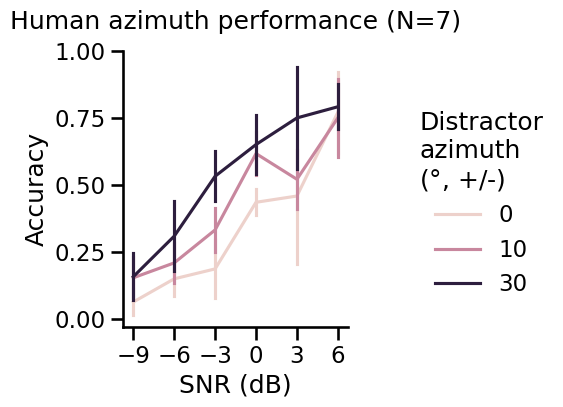

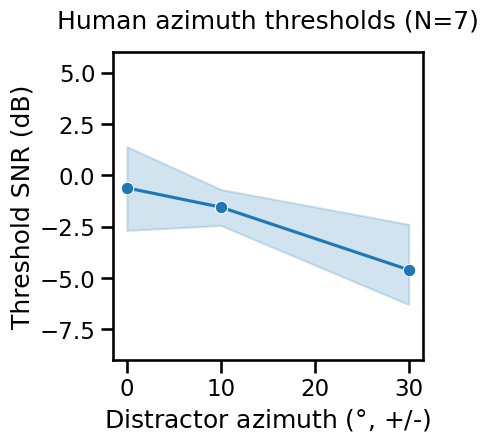

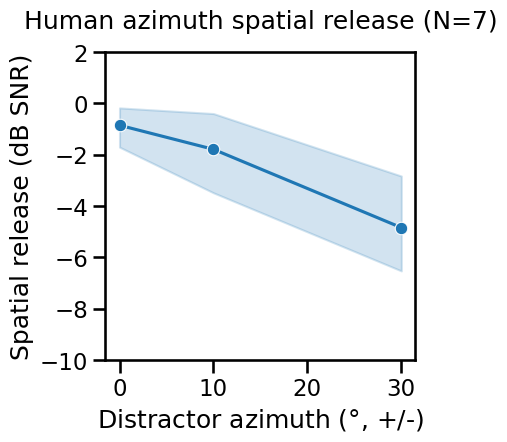

In [22]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 
sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 

azim_results = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim.isin([0, 10, 30])) & (grouped_part_results.n_distractors == 2)].copy()
azim_results_for_thresh = azim_results.groupby(['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = azim_results.participant.nunique() 


azim_results_for_thresh = azim_results_for_thresh[azim_results_for_thresh['snr'].isin(np.arange(-9, 7))]

azim_thresholds = []
# p0 = [0.0, -4, 4]

# fit participant thresholds 

for (part, azim), group in azim_results_for_thresh.groupby(['participant', 'distractor_azim']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for azim {azim}")
    azim_thresholds.append({'participant': part, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_azim_thresh_df = pd.DataFrame(azim_thresholds)

# adjust srm per participant
for part in human_azim_thresh_df.participant.unique():
    part_data = human_azim_thresh_df[human_azim_thresh_df.participant == part]
    human_azim_thresh_df.loc[human_azim_thresh_df.participant == part, 'srm'] = part_data.threshold - part_data.threshold.max()


plt.figure()
g = sns.relplot(data=azim_results[azim_results.snr.isin(np.arange(-9, 7,3))],
                x='snr', y='correct_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
plt.title(f'Human azimuth performance (N={N})', y=1.05)

# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_azim_thresh_df, x='azim', y='threshold', marker='o', errorbar=('ci', 95))

plt.title(f'Human azimuth thresholds (N={N})', y=1.05)
plt.xlabel('Distractor azimuth ($\degree$, +/-)')
plt.ylabel("Threshold SNR (dB)")
plt.ylim(-9,6)


# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_azim_thresh_df, x='azim', y='srm', marker='o')

plt.title(f'Human azimuth spatial release (N={N})', y=1.05)
plt.xlabel('Distractor azimuth ($\degree$, +/-)')
plt.ylabel("Spatial release (dB SNR)")
plt.ylim(-10,2)

### Plot thresholds using average over subject performance

In [63]:
human_azim_thresh_df.groupby('azim').threshold.mean().max()

-0.6904289426228953

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

(-10.0, 2.0)

<Figure size 640x480 with 0 Axes>

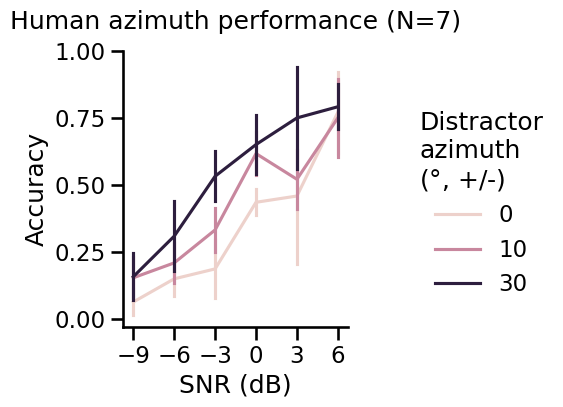

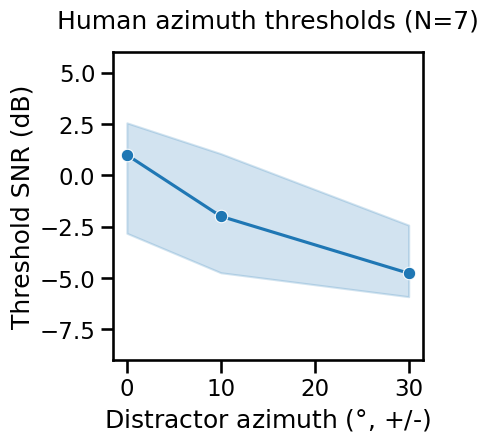

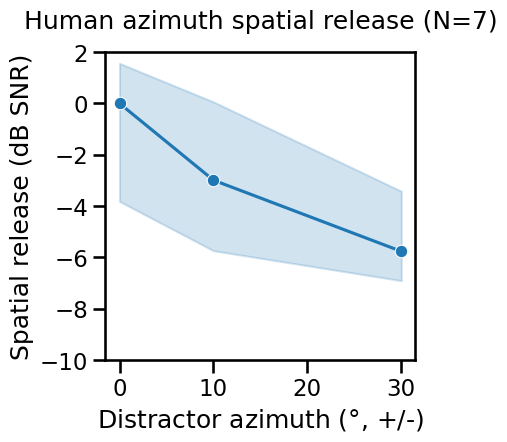

In [24]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 
sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 
azim_results = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim.isin([0, 10, 30])) & (grouped_part_results.n_distractors == 2)].copy()
N = azim_results.participant.nunique() 

# azim_results_for_thresh = azim_results_for_thresh[azim_results_for_thresh['snr'].isin(np.arange(-9, 7))]
part_names = azim_results.participant.unique()

## Bootstrap thresholds 
azim_thresholds = []
n_boot = 1000
# p0 = [0.0, -4, 4]
for azim, group in azim_results.groupby(['distractor_azim']): #, 'gender_cond']):
    for _ in tqdm(range(n_boot), total=n_boot, leave=False):
        group_samp = np.random.choice(part_names, N, replace=True)
        samp_data = group[group.participant.isin(group_samp)]
        samp_data = samp_data.groupby(['distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(samp_data.snr.values, samp_data.correct_mean.values, bounds_from_data=True)#, p0=p0)
        if np.isnan(thresh):
            print(f"Threshold is nan for azim {azim}")
        azim_thresholds.append({'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_azim_thresh_df = pd.DataFrame(azim_thresholds)

# get grouped
human_azim_thresh_df['srm'] = human_azim_thresh_df.threshold - human_azim_thresh_df.groupby('azim').threshold.mean().max()

plt.figure()
g = sns.relplot(data=azim_results[azim_results.snr.isin(np.arange(-9, 7,3))],
                x='snr', y='correct_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
plt.title(f'Human azimuth performance (N={N})', y=1.05)

# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_azim_thresh_df, x='azim', y='threshold', marker='o', errorbar=('pi', 95))

plt.title(f'Human azimuth thresholds (N={N})', y=1.05)
plt.xlabel('Distractor azimuth ($\degree$, +/-)')
plt.ylabel("Threshold SNR (dB)")
plt.ylim(-9,6)


# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_azim_thresh_df, x='azim', y='srm', marker='o',  errorbar=('pi', 95))

plt.title(f'Human azimuth spatial release (N={N})', y=1.05)
plt.xlabel('Distractor azimuth ($\degree$, +/-)')
plt.ylabel("Spatial release (dB SNR)")
plt.ylim(-10,2)

In [65]:
# elev_results.participant.unique()

In [ ]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 

# avg threshold estimates for 0 and 10 elevuth separation 
elev_results = grouped_part_results[(grouped_part_results.distractor_azim == 0)  & (grouped_part_results.n_distractors == 2)].copy()
elev_results = elev_results[(elev_results['snr'].isin(np.arange(-9, 7)))]
elev_results = elev_results[~elev_results.participant.str.contains('pilot')]
# )]

elev_results_for_thresh = elev_results.groupby(['participant', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = elev_results.participant.nunique() 
part_names = elev_results.participant.unique()


# elev_results_for_thresh = elev_results_for_thresh[(elev_results_for_thresh['snr'].isin(np.arange(-9, 7)))]
elev_thresholds = []
n_boot = 1000


p0 = None # [0.1, -3, 1]
for (part, elev), group in elev_results.groupby(['participant', 'distractor_elev_delta']): #, 'gender_cond']):
        group_samp = np.random.choice(part_names, N, replace=True)
        samp_data = group[group.participant.isin(group_samp)]
        samp_data = samp_data.groupby(['distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()

        thresh, fit_popt, _ = util_analysis.estimate_thresholds(samp_data.snr.values,
                                                                 samp_data.correct_mean.values,
                                                                 bounds_from_data=True)
    # if np.isnan(thresh):
        # print(f"Threshold is nan for elev {elev}")
        elev_thresholds.append({'elev': elev, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_elev_thresh_df = pd.DataFrame(elev_thresholds)


plt.figure()
g = sns.relplot(data=elev_results[elev_results.snr.isin(np.arange(-9, 7,3))],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1.1)

g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta\n($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
plt.title(f'Human elevation performance (N={N})', y=1.05)
ratio = 1 
# set titles for each column 
for ax in g.axes.flat:
	xleft, xright = ax.get_xlim()
	ybottom, ytop = ax.get_ylim()
	ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
	for axis in ['bottom','left']:
		ax.spines[axis].set_linewidth(1.5)

human_elev_thresh_df['srm'] = human_elev_thresh_df.threshold - human_elev_thresh_df.threshold.max()

# plot elev thresholds
sns.set_context('talk')
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_elev_thresh_df, x='elev', y='threshold', marker='o', errorbar=('pi', 95))

N = elev_results.participant.nunique() 
plt.title(f'Human elevation thresholds (N={N})', y=1.05)
plt.xlabel('Distractor elevation delta ($\degree$)')
plt.ylabel("Threshold SNR (dB)")
plt.ylim(-6,6)


# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_elev_thresh_df, x='elev', y='srm', marker='o', errorbar=('pi', 95))

plt.title(f'Human elevation spatial release (N={N})', y=1.05)
plt.xlabel('Distractor elevation delta ($\degree$)')
plt.ylabel("Spatial release (dB SNR)")
plt.ylim(-10,2)



In [67]:
group

,distractor_elev_delta,snr,correct_mean
0,0,-9,0.026786
1,0,-8,0.187500
2,0,-6,0.131944
3,0,-4,0.187500
4,0,-3,0.184524
5,0,-2,0.562500
6,0,0,0.438368
7,0,3,0.479167
8,0,6,0.697917


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

(-10.0, 2.0)

<Figure size 640x480 with 0 Axes>

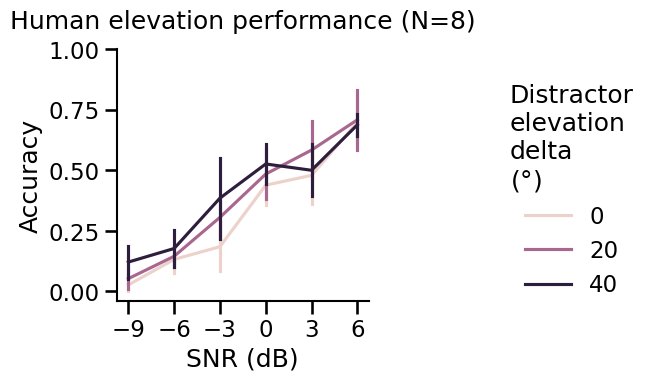

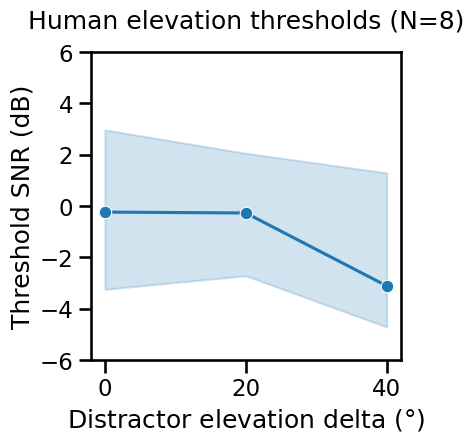

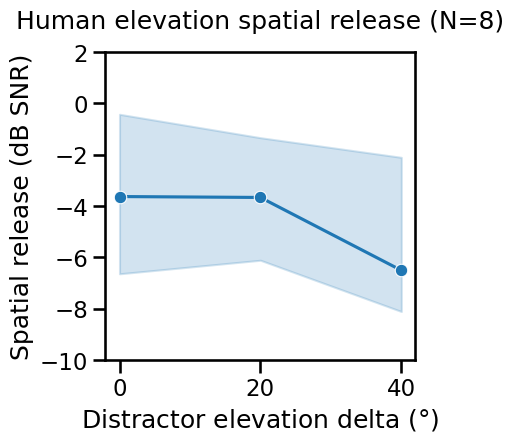

In [68]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 

# avg threshold estimates for 0 and 10 elevuth separation 
elev_results = grouped_part_results[(grouped_part_results.distractor_azim == 0)  & (grouped_part_results.n_distractors == 2)].copy()
elev_results = elev_results[(elev_results['snr'].isin(np.arange(-9, 7)))]
elev_results = elev_results[~elev_results.participant.str.contains('pilot')]
# )]

elev_results_for_thresh = elev_results.groupby(['distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = elev_results.participant.nunique() 
part_names = elev_results.participant.unique()


# elev_results_for_thresh = elev_results_for_thresh[(elev_results_for_thresh['snr'].isin(np.arange(-9, 7)))]
elev_thresholds = []
n_boot = 1000


p0 = None # [0.1, -3, 1]
for elev, group in elev_results.groupby(['distractor_elev_delta']): #, 'gender_cond']):
    for _ in tqdm(range(n_boot), total=n_boot, leave=False):
        group_samp = np.random.choice(part_names, N, replace=True)
        samp_data = group[group.participant.isin(group_samp)]
        samp_data = samp_data.groupby(['distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()

        thresh, fit_popt, _ = util_analysis.estimate_thresholds(samp_data.snr.values,
                                                                 samp_data.correct_mean.values,
                                                                 bounds_from_data=True)
    # if np.isnan(thresh):
        # print(f"Threshold is nan for elev {elev}")
        elev_thresholds.append({'elev': elev, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_elev_thresh_df = pd.DataFrame(elev_thresholds)


plt.figure()
g = sns.relplot(data=elev_results[elev_results.snr.isin(np.arange(-9, 7,3))],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1.1)

g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta\n($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
plt.title(f'Human elevation performance (N={N})', y=1.05)
ratio = 1 
# set titles for each column 
for ax in g.axes.flat:
	xleft, xright = ax.get_xlim()
	ybottom, ytop = ax.get_ylim()
	ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
	for axis in ['bottom','left']:
		ax.spines[axis].set_linewidth(1.5)

human_elev_thresh_df['srm'] = human_elev_thresh_df.threshold - human_elev_thresh_df.threshold.max()

# plot elev thresholds
sns.set_context('talk')
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_elev_thresh_df, x='elev', y='threshold', marker='o', errorbar=('pi', 95))

N = elev_results.participant.nunique() 
plt.title(f'Human elevation thresholds (N={N})', y=1.05)
plt.xlabel('Distractor elevation delta ($\degree$)')
plt.ylabel("Threshold SNR (dB)")
plt.ylim(-6,6)


# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_elev_thresh_df, x='elev', y='srm', marker='o', errorbar=('pi', 95))

plt.title(f'Human elevation spatial release (N={N})', y=1.05)
plt.xlabel('Distractor elevation delta ($\degree$)')
plt.ylabel("Spatial release (dB SNR)")
plt.ylim(-10,2)



# Estimate effect size via bootstrapping thresholds

In [ ]:
azim_data = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim==0)].copy()
azim_data = azim_data[(azim_data.n_distractors == 2)]
# azim_data = azim_data[~azim_data.participant.str.contains("6|7|8")]
# azim_data = azim_data[azim_data.participant != 'participant_001']
azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7))]

In [ ]:
# re.search(r'sample_size_(\d)_subset', file.stem)

(1000,)

(100, 2)

In [10]:
import re 
### Load in bootstrap runs:
bootstrap_results = list(Path('human_loc_power_analysis').glob("*.npy"))
print(len(bootstrap_results))
n_samp_splits = {ix:[] for ix in range(2,8)} # 7 max - 2 min 
for file in bootstrap_results:
    if 'subset' not in file.stem:
        continue
    sample_size = int(re.search(r'sample_size_(\d+)_subset', file.stem).group(1))
    # else:
        # sample_size = int(re.search(r'sizes_(\d+)', file.stem).group(1))
    # use re to get integer index from file path in pattern: "sample_size_{ix}_subset"
    bootstrap_results_array = np.load(file).squeeze()
    if bootstrap_results_array.ndim != 2:
        print(file)
        continue
    if len(n_samp_splits[sample_size]) == 0:
        n_samp_splits[sample_size] = bootstrap_results_array
    else:
        n_samp_splits[sample_size] = np.vstack([n_samp_splits[sample_size], bootstrap_results_array])



600


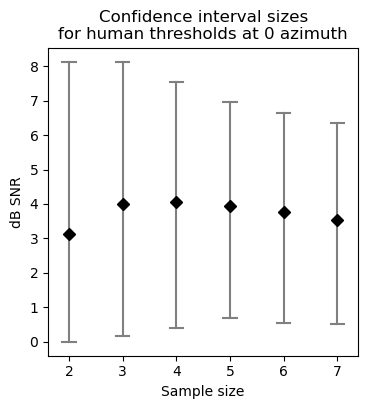

In [14]:
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    data = bootstrap_results_array[:,1]
    ci_means = data.mean()
    # upper_ci = 1.96 * (data.std()/np.sqrt(len(data))) + ci_means
    # lower_ci = ci_means -1.96 * (data.std()/np.sqrt(len(data))) 
    lower_ci, upper_ci = np.nanpercentile(bootstrap_results_array[:,1], [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Confidence interval sizes\nfor human thresholds at 0 azimuth")
plt.xlabel("Sample size")
plt.ylabel("dB SNR")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));

    # axs.plot(sample_size, upper_ci, marker='o')
    # axs.plot(sample_size, mean, marker='o')
    # axs.plot(sample_size, lower_ci, marker='o')
    # plt.errorbar(sample_size, mean,  yerr=upper_ci-lower_ci, alpha=0.3, marker='.')

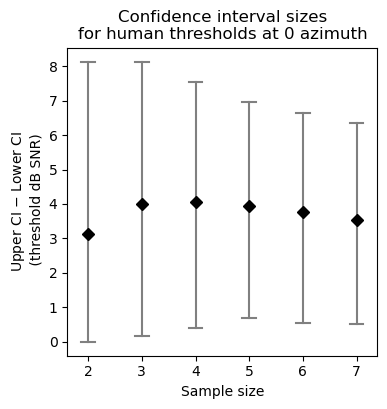

In [9]:
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    ci_means = np.nanmean(bootstrap_results_array[:,1])
    lower_ci, upper_ci = np.nanpercentile(bootstrap_results_array[:,1], [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Confidence interval sizes\nfor human thresholds at 0 azimuth")
plt.xlabel("Sample size")
plt.ylabel("Upper CI $-$ Lower CI\n (threshold dB SNR)")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));

    # axs.plot(sample_size, upper_ci, marker='o')
    # axs.plot(sample_size, mean, marker='o')
    # axs.plot(sample_size, lower_ci, marker='o')
    # plt.errorbar(sample_size, mean,  yerr=upper_ci-lower_ci, alpha=0.3, marker='.')

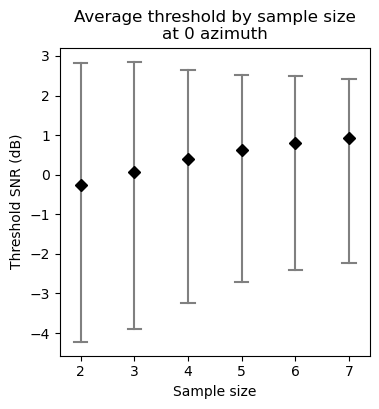

In [10]:
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    ci_means = np.nanmean(bootstrap_results_array[:,0])
    lower_ci, upper_ci = np.nanpercentile(bootstrap_results_array[:,0], [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Average threshold by sample size\nat 0 azimuth")
plt.xlabel("Sample size")
plt.ylabel("Threshold SNR (dB)")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));


In [32]:
## compute threshold for 10 degree azimuth separation

azim_data = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim==10)].copy()
azim_data = azim_data[(azim_data.n_distractors == 2)]
# azim_data = azim_data[~azim_data.participant.str.contains("6|7|8")]
# azim_data = azim_data[azim_data.participant != 'participant_001']
azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7, 3))]

azim_results_for_thresh = azim_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()


azim_10_thresh, fit_popt, _ = util_analysis.estimate_thresholds(azim_results_for_thresh.snr.values, azim_results_for_thresh.correct_mean.values, bounds_from_data=True)
azim_10_thresh

-2.0968512956597825

In [33]:
## compute threshold for 10 degree azimuth separation

azim_data = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim==0)].copy()
azim_data = azim_data[(azim_data.n_distractors == 2)]
# azim_data = azim_data[~azim_data.participant.str.contains("6|7|8")]
# azim_data = azim_data[azim_data.participant != 'participant_001']
azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7, 3))]

azim_results_for_thresh = azim_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()


azim_0_thresh, fit_popt, _ = util_analysis.estimate_thresholds(azim_results_for_thresh.snr.values, azim_results_for_thresh.correct_mean.values, bounds_from_data=True)
azim_0_thresh

2.138539890200451

Text(0.5, 1.0, 'Power as function of\nsample size and SNR difference')

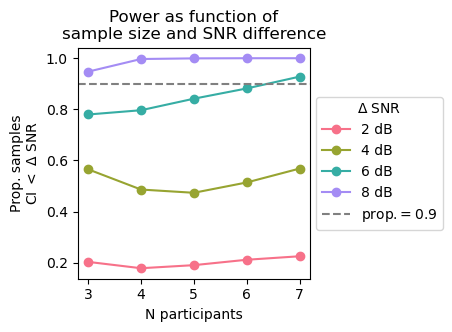

In [75]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB) this is the proportion of trials where the difference in returned confidence intervals is less than or equal to that the SNR
# this means the error in the estimate is small enough to allow for a difference of this magnitude to be reliably measured.  


# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

min_thresholds = list(np.arange(2,10,2)) # dB 

# pick four colors 
colors = sns.color_palette('husl', len(min_thresholds))

samp_sizes = list(n_samp_splits.keys())[1:]
for min_thresh in min_thresholds:   
    props = []
    samps_to_plot = []
    for sample_size, bootstrap_results_array in n_samp_splits.items():
        if len(bootstrap_results_array) == 0:
            continue
        if sample_size == 2:
            continue 
        samps_to_plot.append(sample_size)
        props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))
    plt.plot(samps_to_plot, props,  'o-', color=colors[min_thresholds.index(min_thresh)], label=f"{min_thresh} dB")

    
plt.xlabel("N participants")
plt.ylabel("Prop. samples\nCI $<$ $\Delta$ SNR")
# set x ticks to match sample sizes 
plt.xticks(samp_sizes);
plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')

plt.legend(title='$\Delta$ SNR', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

plt.title(f"Power as function of\nsample size and SNR difference")





[3, 4, 5, 6, 7]


Text(0.5, 1.0, 'Power as function of\nSNR difference and sample size')

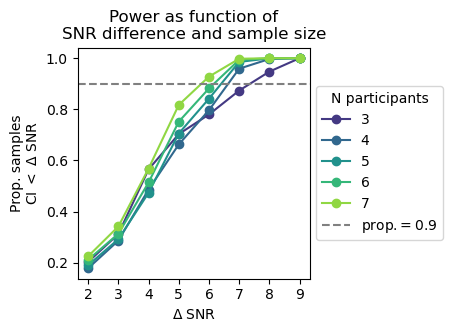

In [76]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB) this is the proportion of trials where the difference in returned confidence intervals is less than or equal to that the SNR
# this means the error in the estimate is small enough to allow for a difference of this magnitude to be reliably measured.  


# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

# pick four colors 

min_thresholds = list(np.arange(2,10)) # dB 
samp_sizes = list(n_samp_splits.keys())[1:]
print(samp_sizes)
colors = sns.color_palette('viridis', len(samp_sizes))

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if sample_size == 2:
        continue
    # if len(bootstrap_results_array) == 0:
    #     continue
    props = []
    # n_good_samp_sizes = 0
    for min_thresh in min_thresholds:   
        props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))

    plt.plot(min_thresholds, props,  'o-', color=colors[samp_sizes.index(sample_size)], label=f"{sample_size}")

    
plt.xlabel("$\Delta$ SNR")
plt.ylabel("Prop. samples\nCI $<$ $\Delta$ SNR")
# set x ticks to match sample sizes 
plt.xticks(min_thresholds);
plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')
plt.legend(title='N participants', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

plt.title(f"Power as function of\nSNR difference and sample size")





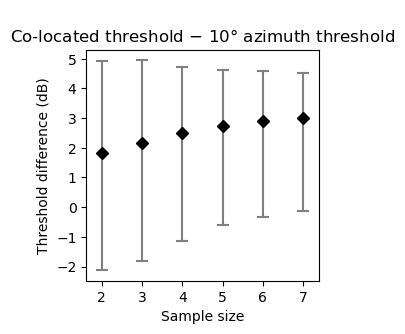

In [78]:
##### Plot difference between estimated 0 azim threshold and population 10 azim threshold 

# azim_data = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim==10)].copy()
# azim_data = azim_data[(azim_data.n_distractors == 2)]
# # azim_data = azim_data[~azim_data.participant.str.contains("6|7|8")]
# # azim_data = azim_data[azim_data.participant != 'participant_001']
# azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7, 3))]

# azim_results_for_thresh = azim_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()

# azim_10_thresh, fit_popt, _ = util_analysis.estimate_thresholds(azim_results_for_thresh.snr.values, azim_results_for_thresh.correct_mean.values, bounds_from_data=True)
# azim_10_thresh

azim_10_thresh = -2.096
plt.figure(figsize=(3, 3))

horizontal_line_width=0.25


for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    # sample 0 azim threshold  - pop 10 azim threshold 
    diffs = bootstrap_results_array[:, 1] 
    mean_diff = np.mean(diffs)
    lower_ci, upper_ci = np.percentile(diffs, [2.5, 97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, mean_diff, 'D', color='k')

plt.title("\nCo-located threshold $-$ 10$\degree$ azimuth threshold")
plt.xlabel("Sample size")
plt.ylabel("Threshold difference (dB)")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));




## Estimate effect size using performance 

In [ ]:
azim_part_data = grouped_part_results[(grouped_part_results.n_distractors==2) &
                                 (grouped_part_results.distractor_elev_delta == 0) &
                                 (grouped_part_results.distractor_azim.isin([0,10]))].groupby(
                                    ['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()

azim_thresholds = []
# p0 = [0.0, -4, 4]
for (part, azim), group in azim_part_data.groupby(['participant', 'distractor_azim']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for {part} at azim {azim}")
    azim_thresholds.append({'participant':part, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_azim_thresh_df = pd.DataFrame(azim_thresholds)

Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for participant_003 at azim 0
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for participant_004 at azim 10


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in true_divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for pilot_participant_002 at azim 10


In [ ]:
azim_part_data = grouped_part_results[(grouped_part_results.n_distractors==2) &
                                 (grouped_part_results.distractor_elev_delta == 0) &
                                 (grouped_part_results.distractor_azim.isin([0,10]))].groupby(
                                    ['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
df_0 = azim_part_data[(azim_part_data.distractor_azim==0) ]
df_10 = azim_part_data[(azim_part_data.distractor_azim==10) ]

# compute cohens d 
snrs = np.arange(-9, 7,3)
cohens_d_scores = []
for snr in snrs:
    df_0_snr = df_0[df_0.snr == snr]
    df_10_snr = df_10[df_10.snr == snr]
    c_d = cohend(df_10_snr.correct_mean, df_0_snr.correct_mean)
    cohens_d_scores.append(abs(c_d))
    print(f"Cohens d for snr {snr}: {c_d}")

print(f"average cohen's d {np.mean(cohens_d_scores)}")
c_d = cohend(df_10.correct_mean, df_0.correct_mean)
print(f"total cohen's d {c_d}")
c_d = cohend(df_10.groupby('snr').correct_mean.mean(), df_0.groupby('snr').correct_mean.mean())
print(f"total cohen's d {c_d}")

Cohens d for snr -9: 1.156870556637974
Cohens d for snr -6: 0.6455562536222988
Cohens d for snr -3: 1.239413799516309
Cohens d for snr 0: 2.0603386415278986
Cohens d for snr 3: 0.36927447293799853
Cohens d for snr 6: -0.1632993161855455
average cohen's d 0.9391255067380042
total cohen's d 0.35878295849665404
total cohen's d 0.11621251809375051


In [ ]:
elev_part_data = grouped_part_results[(grouped_part_results.n_distractors==2) &
                                 (grouped_part_results.distractor_azim == 0) 
                                ].groupby(
                                    ['participant', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
df_0 = elev_part_data[(elev_part_data.distractor_elev_delta==0) ]
df_10 = elev_part_data[(elev_part_data.distractor_elev_delta==20) ]

# compute cohens d 
snrs = np.arange(-9, 7,3)
cohens_d_scores = []
for snr in snrs:
    df_0_snr = df_0[df_0.snr == snr]
    df_10_snr = df_10[df_10.snr == snr]
    c_d = cohend(df_10_snr.correct_mean, df_0_snr.correct_mean)
    cohens_d_scores.append(abs(c_d))
    print(f"Cohens d for snr {snr}: {c_d}")

print(f"average cohen's d {np.mean(cohens_d_scores)}")
c_d = cohend(df_10.correct_mean, df_0.correct_mean)
print(f"total cohen's d {c_d}")
c_d = cohend(df_10.groupby('snr').correct_mean.mean(), df_0.groupby('snr').correct_mean.mean())
print(f"total cohen's d {c_d}")

Cohens d for snr -9: -0.6534884125267567
Cohens d for snr -6: -0.214768711253377
Cohens d for snr -3: 0.8869841880832431
Cohens d for snr 0: 0.7676254820897759
Cohens d for snr 3: 0.11547005383792537
Cohens d for snr 6: -0.20412414523193187
average cohen's d 0.4737434988371683
total cohen's d 0.12458656537246471
total cohen's d -0.10802910931354531


## Run power analysis via bootstrap using participant accuracy

3


  0%|          | 0/2 [00:00<?, ?it/s]

(0.8, 0.9)

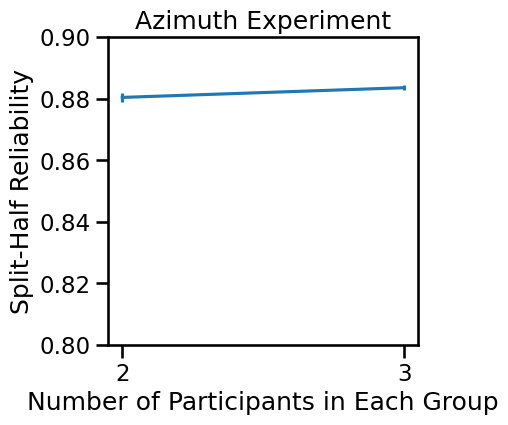

In [ ]:
from tqdm.auto import tqdm
import scipy.stats as stats


# n
## Azim only experiment:
azim_data =  grouped_part_results[grouped_part_results.distractor_elev_delta == 0].copy()
azim_data = azim_data[(azim_data.n_distractors == 2)]
azim_data = azim_data[azim_data.participant != 'participant_001']
azim_data = azim_data[azim_data.snr <= 0]

n_parts = azim_data.participant.nunique()
unique_participants = azim_data.participant.unique()

max_split_size = n_parts // 2
print(max_split_size)

split_half_reliabilities = []
n_boots = 10000

for k in tqdm(range(2, max_split_size+1)):
    # for cond in tqdm(conds, leave=False):
    split_corrs = np.zeros(n_boots)
    for i in range(n_boots):
        # get group 1
        group_1_names = np.random.choice(unique_participants, k, replace=False)
        group_1 = azim_data[azim_data.participant.isin(group_1_names)].correct_mean.values
        # get group 2
        group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
        group_2 = azim_data[azim_data.participant.isin(group_2_names)].correct_mean.values
        # get r
        r = stats.pearsonr(group_1, group_2)[0] 
        split_corrs[i] = r  
    # get condition mean and std
    mean_r = np.nanmean(split_corrs)
    std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
    corrected_mean = (2 * mean_r) / ( 1 + mean_r)
    corrected_error = (2 * std_err) / ( 1 + std_err)

    split_half_reliabilities.append({"k":k, "mean_cor":corrected_mean, "sem": corrected_error})


plt.figure(figsize=(4,4))        
plt.errorbar([x['k'] for x in split_half_reliabilities], [x['mean_cor'] for x in split_half_reliabilities], yerr=[x['sem'] for x in split_half_reliabilities])
plt.xlabel("Number of Participants in Each Group")
plt.ylabel("Split-Half Reliability")
plt.title("Azimuth Experiment")
plt.xticks([x['k'] for x in split_half_reliabilities])
plt.ylim(0.8,0.9)

3


  0%|          | 0/2 [00:00<?, ?it/s]

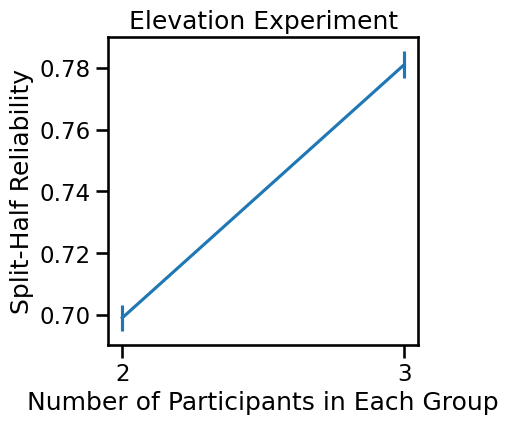

In [ ]:



## Elev only experiment:
elev_data = grouped_part_results[grouped_part_results.distractor_azim == 0].copy()
# elev_data = elev_data[(elev_data.n_distractors == 2)]
elev_data = elev_data[elev_data.participant != 'participant_001']

elev_data.drop(elev_data[(elev_data['participant'].str.contains('pilot')) & (elev_data.n_distractors == 2)].index, inplace=True)


# elev_data = elev_data[~elev_data.participant.str.contains('pilot')]
elev_data = elev_data[elev_data.snr <= 0]

n_parts = elev_data.participant.nunique()
unique_participants = elev_data.participant.unique()

max_split_size = n_parts // 2
print(max_split_size)

split_half_reliabilities = []
n_boots = 10000

for k in tqdm(range(2, max_split_size+1)):
    # for cond in tqdm(conds, leave=False):
    split_corrs = np.zeros(n_boots)
    for i in range(n_boots):
        # get group 1
        group_1_names = np.random.choice(unique_participants, k, replace=False)
        group_1 = elev_data[elev_data.participant.isin(group_1_names)].correct_mean.values
        # get group 2
        group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
        group_2 = elev_data[elev_data.participant.isin(group_2_names)].correct_mean.values
        # get r
        r = stats.pearsonr(group_1, group_2)[0] 
        split_corrs[i] = r  
    # get condition mean and std
    mean_r = np.nanmean(split_corrs)
    std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
    corrected_mean = (2 * mean_r) / ( 1 + mean_r)
    corrected_error = (2 * std_err) / ( 1 + std_err)

    split_half_reliabilities.append({"k":k, "mean_cor":corrected_mean, "sem": corrected_error})

plt.figure(figsize=(4,4))        
plt.errorbar([x['k'] for x in split_half_reliabilities], [x['mean_cor'] for x in split_half_reliabilities], yerr=[x['sem'] for x in split_half_reliabilities])
plt.xlabel("Number of Participants in Each Group")
plt.ylabel("Split-Half Reliability")
plt.title("Elevation Experiment")
plt.xticks([x['k'] for x in split_half_reliabilities]);